<a href="https://colab.research.google.com/github/ivenkateshchigale/Balanace_sheet_analyzer/blob/main/CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Spark Initialization and Data Loading

In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark
spark = SparkSession.builder \
    .appName("PredictiveMaintenancePlatform") \
    .getOrCreate()

print("Spark Version:", spark.version)

Spark Version: 4.0.3


In [ ]:
# Load Dataset
df = spark.read.csv(
    "/content/machine_data.csv",
    header=True,
    inferSchema=True
)

In [ ]:
# Display Dataset
df.show()

# Print Schema
df.printSchema()

# Count Records
print("Total Records:", df.count())

+----------+-----------+---------+--------+----------+----------------+----------------+-------+-----+
|machine_id|temperature|vibration|pressure|production|maintenance_cost|maintenance_date|failure|shift|
+----------+-----------+---------+--------+----------+----------------+----------------+-------+-----+
|      M101|         78|     0.21|     110|       520|            1200|      10-01-2025|      0|    A|
|      M102|         95|     0.65|     130|       410|            2500|      12-01-2025|      1|    B|
|      M103|         70|     0.18|     105|       600|            1000|      05-02-2025|      0|    A|
|      M104|         88|     0.42|     118|       480|            1800|      08-02-2025|      0|    C|
|      M105|         99|     0.75|     135|       390|            3200|      01-03-2025|      1|    B|
|      M106|         82|     0.29|     112|       550|            1400|      10-03-2025|      0|    A|
|      M107|         91|     0.62|     128|       430|            2700|  

Q2. RDD Implementation

In [ ]:
machine_rdd = df.rdd

print(machine_rdd.collect())

[Row(machine_id='M101', temperature=78, vibration=0.21, pressure=110, production=520, maintenance_cost=1200, maintenance_date='10-01-2025', failure=0, shift='A'), Row(machine_id='M102', temperature=95, vibration=0.65, pressure=130, production=410, maintenance_cost=2500, maintenance_date='12-01-2025', failure=1, shift='B'), Row(machine_id='M103', temperature=70, vibration=0.18, pressure=105, production=600, maintenance_cost=1000, maintenance_date='05-02-2025', failure=0, shift='A'), Row(machine_id='M104', temperature=88, vibration=0.42, pressure=118, production=480, maintenance_cost=1800, maintenance_date='08-02-2025', failure=0, shift='C'), Row(machine_id='M105', temperature=99, vibration=0.75, pressure=135, production=390, maintenance_cost=3200, maintenance_date='01-03-2025', failure=1, shift='B'), Row(machine_id='M106', temperature=82, vibration=0.29, pressure=112, production=550, maintenance_cost=1400, maintenance_date='10-03-2025', failure=0, shift='A'), Row(machine_id='M107', temp

In [ ]:
high_temp = machine_rdd.filter(lambda x: x.temperature > 90)

high_temp.collect()

[Row(machine_id='M102', temperature=95, vibration=0.65, pressure=130, production=410, maintenance_cost=2500, maintenance_date='12-01-2025', failure=1, shift='B'),
 Row(machine_id='M105', temperature=99, vibration=0.75, pressure=135, production=390, maintenance_cost=3200, maintenance_date='01-03-2025', failure=1, shift='B'),
 Row(machine_id='M107', temperature=91, vibration=0.62, pressure=128, production=430, maintenance_cost=2700, maintenance_date='02-04-2025', failure=1, shift='C'),
 Row(machine_id='M110', temperature=98, vibration=0.7, pressure=132, production=405, maintenance_cost=3000, maintenance_date='18-05-2025', failure=1, shift='C')]

In [ ]:
production_rdd = machine_rdd.map(lambda x: (x.machine_id, x.production))

production_rdd.collect()

[('M101', 520),
 ('M102', 410),
 ('M103', 600),
 ('M104', 480),
 ('M105', 390),
 ('M106', 550),
 ('M107', 430),
 ('M108', 610),
 ('M109', 500),
 ('M110', 405)]

Q3. Key-Value Operations and Persistence

In [ ]:
production_sum = production_rdd.reduceByKey(lambda a, b: a + b)

production_sum.collect()

[('M101', 520),
 ('M102', 410),
 ('M103', 600),
 ('M104', 480),
 ('M105', 390),
 ('M106', 550),
 ('M107', 430),
 ('M108', 610),
 ('M109', 500),
 ('M110', 405)]

In [ ]:
production_sum.cache()


PythonRDD[32] at collect at /tmp/ipykernel_1281/1026090386.py:3

In [ ]:
production_sum.collect()


[('M101', 520),
 ('M102', 410),
 ('M103', 600),
 ('M104', 480),
 ('M105', 390),
 ('M106', 550),
 ('M107', 430),
 ('M108', 610),
 ('M109', 500),
 ('M110', 405)]

In [ ]:
production_sum.unpersist()

PythonRDD[32] at collect at /tmp/ipykernel_1281/1026090386.py:3

Q4. Spark DataFrame Operations

In [ ]:
df.select("machine_id", "temperature").show()

+----------+-----------+
|machine_id|temperature|
+----------+-----------+
|      M101|         78|
|      M102|         95|
|      M103|         70|
|      M104|         88|
|      M105|         99|
|      M106|         82|
|      M107|         91|
|      M108|         76|
|      M109|         85|
|      M110|         98|
+----------+-----------+



In [ ]:
df.filter(df.temperature > 90).show()


+----------+-----------+---------+--------+----------+----------------+----------------+-------+-----+
|machine_id|temperature|vibration|pressure|production|maintenance_cost|maintenance_date|failure|shift|
+----------+-----------+---------+--------+----------+----------------+----------------+-------+-----+
|      M102|         95|     0.65|     130|       410|            2500|      12-01-2025|      1|    B|
|      M105|         99|     0.75|     135|       390|            3200|      01-03-2025|      1|    B|
|      M107|         91|     0.62|     128|       430|            2700|      02-04-2025|      1|    C|
|      M110|         98|      0.7|     132|       405|            3000|      18-05-2025|      1|    C|
+----------+-----------+---------+--------+----------+----------------+----------------+-------+-----+



In [ ]:
df.groupBy("machine_id").sum("production").show()

+----------+---------------+
|machine_id|sum(production)|
+----------+---------------+
|      M104|            480|
|      M103|            600|
|      M107|            430|
|      M106|            550|
|      M108|            610|
|      M102|            410|
|      M105|            390|
|      M101|            520|
|      M109|            500|
|      M110|            405|
+----------+---------------+



Q5. Exploratory Data Analysis and Spark SQL

In [ ]:
df.createOrReplaceTempView("machines")

In [ ]:
df.createOrReplaceTempView("maintenance")

In [ ]:
spark.sql("""
SELECT machine_id,
       AVG(temperature) AS AvgTemp,
       SUM(production) AS TotalProduction
FROM machines
GROUP BY machine_id
""").show()

+----------+-------+---------------+
|machine_id|AvgTemp|TotalProduction|
+----------+-------+---------------+
|      M104|   88.0|            480|
|      M103|   70.0|            600|
|      M107|   91.0|            430|
|      M106|   82.0|            550|
|      M108|   76.0|            610|
|      M102|   95.0|            410|
|      M105|   99.0|            390|
|      M101|   78.0|            520|
|      M109|   85.0|            500|
|      M110|   98.0|            405|
+----------+-------+---------------+



Q6. ETL Pipeline Development

In [ ]:
maintenance_df = df.select("machine_id", "maintenance_cost", "maintenance_date")

joined_df = df.join(
    maintenance_df,
    on="machine_id",
    how="left"
)

joined_df.show()

+----------+-----------+---------+--------+----------+----------------+----------------+-------+-----+----------------+----------------+
|machine_id|temperature|vibration|pressure|production|maintenance_cost|maintenance_date|failure|shift|maintenance_cost|maintenance_date|
+----------+-----------+---------+--------+----------+----------------+----------------+-------+-----+----------------+----------------+
|      M101|         78|     0.21|     110|       520|            1200|      10-01-2025|      0|    A|            1200|      10-01-2025|
|      M102|         95|     0.65|     130|       410|            2500|      12-01-2025|      1|    B|            2500|      12-01-2025|
|      M103|         70|     0.18|     105|       600|            1000|      05-02-2025|      0|    A|            1000|      05-02-2025|
|      M104|         88|     0.42|     118|       480|            1800|      08-02-2025|      0|    C|            1800|      08-02-2025|
|      M105|         99|     0.75|     13

Q7. Machine Learning/Deep Learning Implementation

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression

assembler = VectorAssembler(
    inputCols=["temperature", "vibration", "production"],
    outputCol="features"
)

data = assembler.transform(df)

train, test = data.randomSplit([0.8, 0.2], seed=42)

lr = LogisticRegression(featuresCol="features", labelCol="failure")

model = lr.fit(train)

predictions = model.transform(test)

predictions.select(
    "machine_id",
    "failure",
    "prediction",
    "probability"
).show(truncate=False)

+----------+-------+----------+-------------------------------------------+
|machine_id|failure|prediction|probability                                |
+----------+-------+----------+-------------------------------------------+
|M103      |0      |0.0       |[1.0,0.0]                                  |
|M107      |1      |1.0       |[2.5272334770482066E-4,0.9997472766522951] |
|M109      |0      |0.0       |[0.9999999999958828,4.1171510645199305E-12]|
+----------+-------+----------+-------------------------------------------+



### Visualizing Model Predictions

Let's visualize the actual vs. predicted failure counts to understand the model's performance.

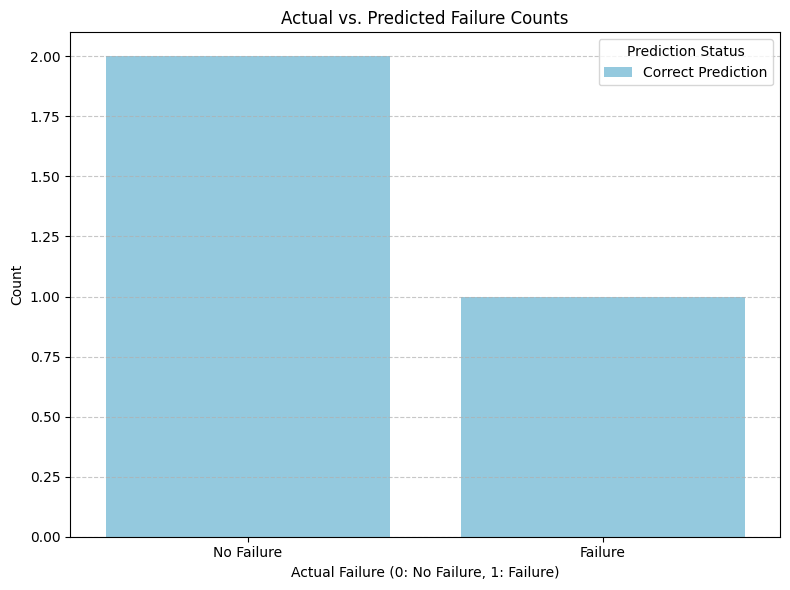

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert predictions to Pandas DataFrame for easier plotting
predictions_pd = predictions.select("failure", "prediction").toPandas()

# Create a new column to indicate the type of observation
predictions_pd['type'] = predictions_pd.apply(lambda row: 'Correct Prediction' if row['failure'] == row['prediction'] else 'Incorrect Prediction', axis=1)

# Prepare data for plotting
plot_data = predictions_pd.groupby(['failure', 'type']).size().reset_index(name='count')

# Create a grouped bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='failure', y='count', hue='type', data=plot_data, palette={'Correct Prediction': 'skyblue', 'Incorrect Prediction': 'salmon'})
plt.title('Actual vs. Predicted Failure Counts')
plt.xlabel('Actual Failure (0: No Failure, 1: Failure)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.legend(title='Prediction Status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class.

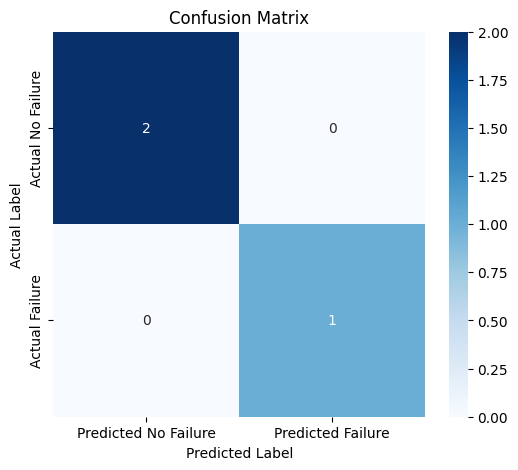

In [29]:
from sklearn.metrics import confusion_matrix


# Calculate the confusion matrix
cm = confusion_matrix(predictions_pd['failure'], predictions_pd['prediction'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Failure', 'Predicted Failure'],
            yticklabels=['Actual No Failure', 'Actual Failure'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Feature Distributions by Failure Status

These plots help visualize if there's a noticeable difference in feature values between machines that failed and those that didn't.

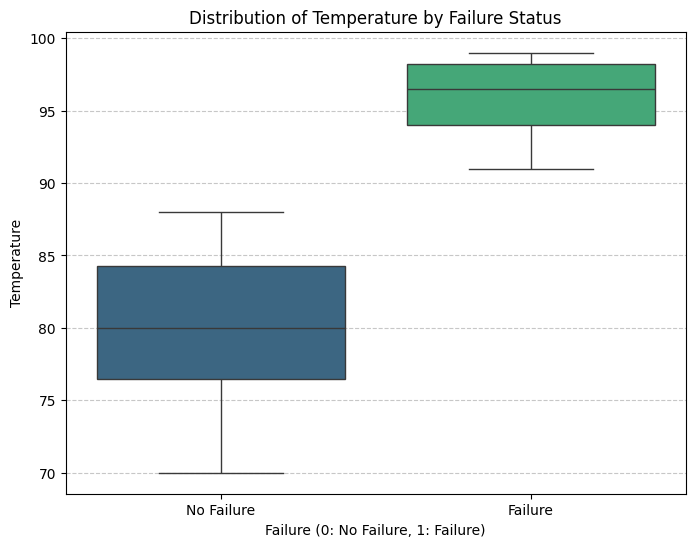

In [32]:
# Convert the Spark DataFrame 'data' (which includes features and the 'failure' label) to Pandas for plotting
data_for_plots_pd = data.select("failure", "temperature", "vibration", "production").toPandas()

# Chart 2: Distribution of Temperature by Failure
plt.figure(figsize=(8, 6))
sns.boxplot(x='failure', y='temperature', hue='failure', data=data_for_plots_pd, palette='viridis', legend=False)
plt.title('Distribution of Temperature by Failure Status')
plt.xlabel('Failure (0: No Failure, 1: Failure)')
plt.ylabel('Temperature')
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

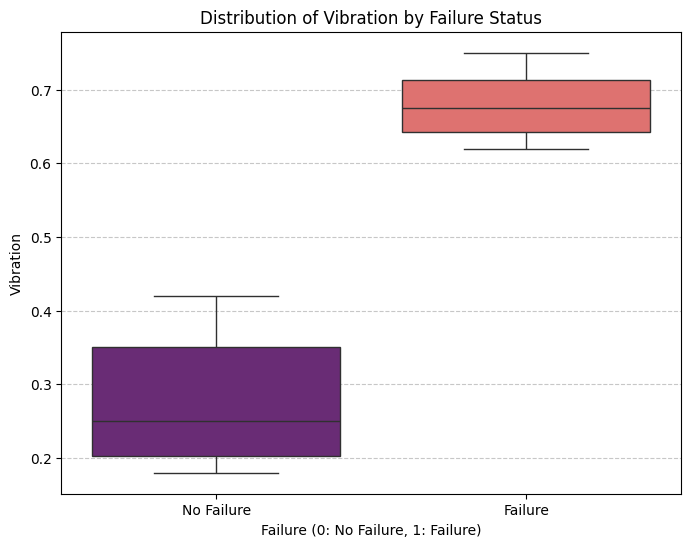

In [33]:
# Chart 3: Distribution of Vibration by Failure
plt.figure(figsize=(8, 6))
sns.boxplot(x='failure', y='vibration', hue='failure', data=data_for_plots_pd, palette='magma', legend=False)
plt.title('Distribution of Vibration by Failure Status')
plt.xlabel('Failure (0: No Failure, 1: Failure)')
plt.ylabel('Vibration')
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()